(04-20-voorspelbaarheid)=

# Voorspelbaarheid van rendementen

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1988–2011, van Fama-French en Campbell-Shiller tot Cochrane's
presidential address.

**Wat we al weten.** In [](#01-03-williams-ddm) voorspelde de
prijs-dividend-ratio het tienjaarsrendement en niet de tienjaarsgroei van
dividenden; onder de identiteit van Williams betekent dat dat de discontovoet
beweegt. In [](#03-15-shiller-excess-volatility) bleek dezelfde ratio meer te
bewegen dan dividendnieuws kan dragen, en in [](#03-10-merton-icapm) zagen we dat
een langetermijnbelegger zijn portefeuille op die voorspelbaarheid zou bouwen,
terwijl de helling waarop alles rust een $t$-waarde rond de twee heeft en omhoog
vertekend is. [](#04-19-momentum) liet een voortzetting van rendementen zien in
de *cross-sectie*; hier gaat het om de tijdreeks van de markt als geheel.

**Welke vraag staat open.** Zijn rendementen op de aandelenmarkt voorspelbaar, en
zo ja: kun je dat met een eeuw data aantonen, en kun je er iets mee?
```

## Overzicht

In 1988 verschenen twee artikelen die de vraag "zijn rendementen voorspelbaar?"
van een randprobleem tot een hoofdprobleem maakten. Eugene Fama en Kenneth French
lieten zien dat de dividendopbrengst maandrendementen nauwelijks voorspelt maar
twee- tot vierjaarsrendementen des te beter {cite}`FamaFrench1988`. John
Campbell en Robert Shiller gaven het boekhoudkundige kader waarin zo'n
bevinding moet worden gelezen: een log-lineaire versie van de
contante-waardeformule die de variantie van de dividend-prijsratio exact
verdeelt over verwachte rendementen en verwachte dividendgroei
{cite}`CampbellShiller1988`. Samen verschoven ze de discussie over efficiënte
markten van "zijn rendementen onvoorspelbaar?" naar "*hoeveel* van de variatie in
prijzen is variatie in verwachte rendementen?". Twintig jaar later gaf John
Cochrane het antwoord dat vandaag de standaard is: vrijwel alles
{cite}`Cochrane2008,Cochrane2011`.

Die twintig jaar zijn het interessante deel. Stambaugh liet zien dat de
voorspellende regressie in kleine steekproeven omhoog vertekend is
{cite}`Stambaugh1999`; Hodrick en Valkanov dat de $t$-waarden van
lange-horizonregressies met overlappende waarnemingen te optimistisch zijn
{cite}`Hodrick1992,Valkanov2003`; en Goyal en Welch dat vrijwel geen enkele
voorspeller het historische gemiddelde *uit de steekproef* verslaat
{cite}`GoyalWelch2008`. Daartegenover staan drie verdedigingen: Cochrane's
argument dat niet de aanwezigheid van rendementsvoorspelbaarheid maar de
*afwezigheid* van dividendvoorspelbaarheid het bewijs levert, het argument van
Campbell en Thompson dat een kleine $R^2$ economisch groot kan zijn
{cite}`CampbellThompson2008`, en de methode van Ferreira en Santa-Clara die
het rendement in drie stukken knipt en elk stuk apart voorspelt
{cite}`FerreiraSantaClara2011`.

Epistemisch is dit een lecture over een *feit*, niet over een theorie: dat de
dividend-prijsratio beweegt door verwachte rendementen volgt uit boekhouding plus
data, en de theorieën die het moeten verklaren komen pas later. Motief 1 staat
centraal: de $R^2$ is klein, de economische waarde groot, en de data die nodig zijn
om dat te zien, zijn er nauwelijks. We repliceren Fama en French' lange-horizontabel,
Cochrane's tabellen 1–3, de out-of-sampletabel van Goyal en Welch en de
sum-of-the-parts-$R^2$ van Ferreira en Santa-Clara op `hap.data.goyal_welch()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Een aandeel is duur ten opzichte van zijn dividend om precies twee redenen: of
beleggers verwachten dat het dividend hard gaat groeien, of ze nemen genoegen met
een laag rendement. Een derde reden is er niet, afgezien van een bel die voor altijd
blijft groeien; dat volgt uit de definitie van rendement. De dividend-prijsratio moet
dus *iets* voorspellen: dividendgroei, rendementen, of een mengsel.

Neem nu de data. De Amerikaanse dividend-prijsratio schommelt sinds 1926 tussen
ruwweg 1% en 8% en keert traag terug naar zijn gemiddelde: een afwijking is na tien
jaar nog voor ruim de helft aanwezig. Als die schommelingen over dividenden gingen,
zou je na dure jaren snelle dividendgroei moeten zien. Die zie je niet. Dan blijft er
maar één kanaal over: na dure jaren komen lage rendementen. Dat is Cochrane's "dog
that did not bark", naar het verhaal van Sherlock Holmes waarin de hond die 's nachts
níet blafte de beslissende aanwijzing was.

Waarom is de voorspelbaarheid dan zo moeilijk te zien? Omdat het verwachte
rendement weinig beweegt ten opzichte van het rendement zelf. Als het verwachte
jaarrendement schommelt met een standaarddeviatie van vier procentpunt en het
gerealiseerde rendement met twintig, dan verklaart de voorspeller per jaar
hooguit $4^2/20^2 = 4\%$ van de variantie. Maar die vier procentpunt is persistent:
wie tien jaar belegt vanuit een dure markt, krijgt tien jaar lang een iets lager
verwacht rendement, en tien kleine verschillen tellen op tot één groot verschil.
De ruis daarentegen middelt uit. Daarom groeit de $R^2$ met de horizon, en daarom
zochten Fama en French het bewijs bij twee- tot vierjaarsrendementen en niet bij
maandrendementen.

Dezelfde persistentie maakt de statistiek verraderlijk. Een voorspeller die bijna
een random walk is, heeft over een eeuw maar een handvol onafhankelijke
schommelingen; de schatter is vertekend en de $t$-waarden zijn te mooi. En wie de
voorspelling in realtime had willen gebruiken, had zijn helling moeten schatten op
de data van dat moment. Zo komen we bij de paradox van dit tijdvak: het bewijs dat
verwachte rendementen variëren is sterk, het bewijs dat je daar als belegger iets
aan hebt, is zwak, en die twee uitspraken zijn met elkaar te verzoenen.

## Toy-voorbeeld: vier jaar data en de identiteit van Cochrane

We nemen vier jaar data, gemeten als afwijking van het langjarige gemiddelde
zodat alle constanten wegvallen. De log dividend-prijsratio $dp_t = d_t - p_t$ is

$$
dp_0 = -0{,}10, \qquad dp_1 = 0{,}00, \qquad dp_2 = 0{,}10, \qquad dp_3 = 0{,}16 ,
$$

en de log dividendgroei in jaar 1, 2 en 3 is $\Delta d_1 = 0{,}02$,
$\Delta d_2 = 0{,}06$, $\Delta d_3 = 0{,}01$. De rendementen volgen uit de
Campbell-Shiller-benadering die we in de theorie afleiden,
$r_{t+1} = dp_t - \rho\, dp_{t+1} + \Delta d_{t+1}$, met $\rho = 0{,}96$:

$$
\begin{aligned}
r_1 &= -0{,}10 - 0{,}96 \times 0{,}00 + 0{,}02 = -0{,}0800, \\
r_2 &= \phantom{-}0{,}00 - 0{,}96 \times 0{,}10 + 0{,}06 = -0{,}0360, \\
r_3 &= \phantom{-}0{,}10 - 0{,}96 \times 0{,}16 + 0{,}01 = -0{,}0436 .
\end{aligned}
$$

Het zijn afwijkingen van een gemiddeld rendement, dus negatieve getallen
betekenen hier "onder het gemiddelde", geen verlies.

**Drie regressies met de hand.** De regressor is $x = (dp_0, dp_1, dp_2) =
(-0{,}10;\ 0{,}00;\ 0{,}10)$ met gemiddelde nul en $\sum x^2 = 0{,}02$. Omdat
$\sum x = 0$ is een OLS-helling gewoon $\sum x\,y / 0{,}02$, zonder eerst $y$ te
demeanen:

$$
\begin{aligned}
\hat\phi &= \frac{(-0{,}10)(0{,}00) + (0{,}00)(0{,}10) + (0{,}10)(0{,}16)}{0{,}02} = \frac{0{,}016}{0{,}02} = 0{,}80, \\
\hat b_d &= \frac{(-0{,}10)(0{,}02) + (0{,}00)(0{,}06) + (0{,}10)(0{,}01)}{0{,}02} = \frac{-0{,}001}{0{,}02} = -0{,}05, \\
\hat b_r &= \frac{(-0{,}10)(-0{,}0800) + (0{,}00)(-0{,}0360) + (0{,}10)(-0{,}0436)}{0{,}02} = \frac{0{,}00364}{0{,}02} = 0{,}182 .
\end{aligned}
$$

**De identiteit.** Nu de controle die de hele lecture draagt:
$1 - \rho\hat\phi + \hat b_d = 1 - 0{,}96 \times 0{,}80 - 0{,}05 = 1 - 0{,}768 - 0{,}05 =
0{,}182 = \hat b_r$. De drie hellingen zijn niet onafhankelijk: wie er twee kent,
kent de derde. Delen door $1 - \rho\hat\phi = 0{,}232$ geeft de "lange-termijn"-versie,
$\hat b_r/0{,}232 = 0{,}7845$ en $\hat b_d/0{,}232 = -0{,}2155$, en hun verschil is
precies één. In dit verzonnen voorbeeld komt dus 78% van de beweging in $dp$ uit
verwachte rendementen en 22% uit verwachte dividendgroei.

**De lange horizon.** Neem Cochrane's afgeronde schattingen $b_r = 0{,}10$ en
$\phi = 0{,}94$. Als $dp$ een AR(1) is, voorspelt $dp_t$ het rendement over jaar
$t+j$ met helling $b_r\phi^{j-1}$, en de helling op het cumulatieve rendement over
$k$ jaar is de meetkundige som

$$
b_r^{(k)} = b_r \frac{1-\phi^k}{1-\phi}: \qquad
b_r^{(1)} = 0{,}100,\quad
b_r^{(5)} = 0{,}10 \times \frac{1 - 0{,}7339}{0{,}06} = 0{,}4435,\quad
b_r^{(10)} = 0{,}10 \times \frac{1 - 0{,}5386}{0{,}06} = 0{,}7690 ,
$$

oplopend naar $0{,}10/0{,}06 = 1{,}667$ op oneindige horizon. Met de discontering
$\rho$ uit de identiteit wordt de oneindige som $b_r/(1-\rho\phi) = 0{,}10/(1 - 0{,}96
\times 0{,}94) = 0{,}10/0{,}0976 = 1{,}0246$: één log-punt hogere $dp$ voorspelt ongeveer één log-punt
hoger verdisconteerd rendement. Dat is het getal dat Cochrane $b_r^{lr}$ noemt.

In [2]:
rho_toy = 0.96
dp_toy = np.array([-0.10, 0.00, 0.10, 0.16])
dd_toy = np.array([0.02, 0.06, 0.01])
r_toy = dp_toy[:-1] - rho_toy * dp_toy[1:] + dd_toy


def ols_slope(y, x):
    """OLS slope of y on x with an intercept."""
    xd = x - x.mean()
    return float((xd * (y - y.mean())).sum() / (xd**2).sum())


x_toy = dp_toy[:-1]
phi_toy = ols_slope(dp_toy[1:], x_toy)
bd_toy = ols_slope(dd_toy, x_toy)
br_toy = ols_slope(r_toy, x_toy)

print("rendementen        :", np.round(r_toy, 4), "  (hand: -0.0800, -0.0360, -0.0436)")
print(f"phi, b_d, b_r      : {phi_toy:.4f}, {bd_toy:.4f}, {br_toy:.4f}   (hand: 0.8000, -0.0500, 0.1820)")
print(f"1 - rho*phi + b_d  : {1 - rho_toy * phi_toy + bd_toy:.4f}   (hand: 0.1820)")
print(f"b_r^lr, b_d^lr     : {br_toy / (1 - rho_toy * phi_toy):.4f}, "
      f"{bd_toy / (1 - rho_toy * phi_toy):.4f}   (hand: 0.7845, -0.2155)")

b_c, phi_c = 0.10, 0.94
horizon_coef = {k: b_c * (1 - phi_c**k) / (1 - phi_c) for k in (1, 5, 10)}
print("b_r^(k), k = 1, 5, 10:", {k: round(v, 4) for k, v in horizon_coef.items()},
      "  (hand: 0.1000, 0.4435, 0.7690)")
print(f"b_r / (1 - rho*phi) : {b_c / (1 - rho_toy * phi_c):.4f}   (hand: 1.0246)")

rendementen        : [-0.08   -0.036  -0.0436]   (hand: -0.0800, -0.0360, -0.0436)
phi, b_d, b_r      : 0.8000, -0.0500, 0.1820   (hand: 0.8000, -0.0500, 0.1820)
1 - rho*phi + b_d  : 0.1820   (hand: 0.1820)
b_r^lr, b_d^lr     : 0.7845, -0.2155   (hand: 0.7845, -0.2155)
b_r^(k), k = 1, 5, 10: {1: 0.1, 5: 0.4435, 10: 0.769}   (hand: 0.1000, 0.4435, 0.7690)
b_r / (1 - rho*phi) : 1.0246   (hand: 1.0246)


De code geeft dezelfde getallen als de hand. De identiteit in de derde regel geldt
in de steekproef exact zodra de rendementen uit de linearisatie komen; in echte data
op een paar duizendsten na.

## Theorie

Vanaf hier zijn kleine letters logs: $p_t = \log P_t$, $d_t = \log D_t$,
$r_{t+1} = \log R_{t+1}$, en $dp_t = d_t - p_t$ is de log dividend-prijsratio. We
volgen de tekenconventie van Cochrane ($d - p$, dus hoog is goedkoop) in plaats
van die van Campbell en Shiller ($p - d$); de formules verschillen alleen in
het teken.

### De Campbell-Shiller-loglinearisatie

*Waarom zou dit waar zijn?* Het rendement is het dividendrendement plus de
koerswinst. In logs wordt dat een niet-lineaire functie van de prijs-dividendratio
van morgen, maar die ratio schommelt rond een stabiel gemiddelde, en een gladde
functie is dicht bij zijn gemiddelde bijna een rechte lijn. Vervang de functie door
die lijn en het rendement wordt een lineaire combinatie van de ratio van vandaag,
de ratio van morgen en de dividendgroei. Een lineaire differentievergelijking kun
je vooruit oplossen, en dan staat er een contante-waardeformule in logs.

:::{prf:proposition} Campbell-Shiller-identiteit
:label: thm-voorspelbaarheid-cs

Laat $\overline{pd}$ het gemiddelde van $p_t - d_t$ zijn en definieer
$\rho = e^{\overline{pd}}/(1 + e^{\overline{pd}})$ en
$\kappa = \log(1 + e^{\overline{pd}}) - \rho\,\overline{pd}$. Tot op tweede-orde
termen in $pd_{t+1} - \overline{pd}$ geldt

```{math}
:label: eq-voorspelbaarheid-cs-rendement
r_{t+1} \approx \kappa - \rho\, dp_{t+1} + \Delta d_{t+1} + dp_t .
```

Als bovendien $\lim_{k\to\infty}\rho^k dp_{t+k} = 0$, dan geldt ex post en dus
ook in verwachting op $t$

```{math}
:label: eq-voorspelbaarheid-cs-pv
dp_t \approx -\frac{\kappa}{1-\rho}
  + \sum_{j=1}^{\infty} \rho^{j-1} r_{t+j}
  - \sum_{j=1}^{\infty} \rho^{j-1} \Delta d_{t+j}
\;=\; -\frac{\kappa}{1-\rho}
  + \E_t\!\sum_{j=1}^{\infty} \rho^{j-1} r_{t+j}
  - \E_t\!\sum_{j=1}^{\infty} \rho^{j-1} \Delta d_{t+j} .
```
:::

:::{prf:proof}
:class: dropdown

Schrijf het bruto rendement als

$$
R_{t+1} = \frac{P_{t+1} + D_{t+1}}{P_t}
= \left(1 + \frac{P_{t+1}}{D_{t+1}}\right)\frac{D_{t+1}}{D_t}\,\frac{D_t}{P_t} .
$$

Neem logs, met $pd = p - d$:
$r_{t+1} = \log\!\left(1 + e^{pd_{t+1}}\right) + \Delta d_{t+1} - pd_t$. Dit is exact.
De functie $f(x) = \log(1 + e^x)$ heeft $f'(x) = e^x/(1+e^x)$ en
$f''(x) = f'(x)\,(1 - f'(x))$. Een eerste-orde Taylorbenadering rond $\overline{pd}$
geeft $f(pd_{t+1}) \approx f(\overline{pd}) + \rho\,(pd_{t+1} - \overline{pd}) =
\kappa + \rho\, pd_{t+1}$, met een fout van
$\tfrac12\rho(1-\rho)(pd_{t+1} - \overline{pd})^2$ plus hogere termen. Invullen en
$pd = -dp$ gebruiken geeft [](#eq-voorspelbaarheid-cs-rendement).

Herschrijf [](#eq-voorspelbaarheid-cs-rendement) als
$dp_t = -\kappa + r_{t+1} - \Delta d_{t+1} + \rho\, dp_{t+1}$ en substitueer
dezelfde vergelijking voor $dp_{t+1}$, $dp_{t+2}$, enzovoort. Na $k$ stappen:

$$
dp_t = -\kappa\sum_{j=0}^{k-1}\rho^j + \sum_{j=1}^{k}\rho^{j-1}\left(r_{t+j} - \Delta d_{t+j}\right) + \rho^k dp_{t+k}.
$$

Omdat $0 < \rho < 1$ convergeert $\sum \rho^j$ naar $1/(1-\rho)$, en onder de
voorwaarde $\rho^k dp_{t+k} \to 0$ verdwijnt de laatste term. Dit is een uitspraak
over gerealiseerde grootheden; omdat $dp_t$ bekend is op $t$, geldt hij ook na het
nemen van $\E_t$ aan beide kanten. $\square$
:::

Drie opmerkingen. $\rho$ is geen voorkeursparameter maar een getal uit de data: bij
een gemiddelde prijs-dividendratio van 25 is $\rho = 25/26 = 0{,}96$.
[](#eq-voorspelbaarheid-cs-pv) is de log-lineaire tegenhanger van Williams'
[](#eq-williams-ddm-pd), die in [](#03-15-shiller-excess-volatility) al als
variantiegrens diende. En de benaderingsfout is klein: bij een afwijking van 0,5 in
de log-ratio is de tweede-ordeterm $\tfrac12 \times 0{,}96 \times 0{,}04 \times 0{,}25
= 0{,}005$.

### De variantiedecompositie

*Waarom zou dit waar zijn?* Als de ratio van vandaag gelijk is aan verdisconteerde
toekomstige rendementen min verdisconteerde toekomstige dividendgroei, dan moet
elke afwijking van de ratio van zijn gemiddelde terugkomen in een van die twee
sommen. Vermenigvuldig beide kanten met die afwijking en neem verwachtingen: links
staat de variantie, rechts twee covarianties, en die covarianties zijn niets anders
dan voorspelbaarheid.

Vermenigvuldig [](#eq-voorspelbaarheid-cs-pv) met $dp_t - \E[dp_t]$ en neem
onvoorwaardelijke verwachtingen:

```{math}
:label: eq-voorspelbaarheid-decompositie
\Var(dp_t) = \Cov\!\Big(dp_t,\ \sum_{j\ge1}\rho^{j-1} r_{t+j}\Big)
           - \Cov\!\Big(dp_t,\ \sum_{j\ge1}\rho^{j-1} \Delta d_{t+j}\Big) .
```

Deel door $\Var(dp_t)$ en de covarianties worden regressiecoëfficiënten:

```{math}
:label: eq-voorspelbaarheid-lr
1 = b_r^{lr} - b_d^{lr}, \qquad
b_r^{lr} = \beta\!\Big(\sum_{j\ge1}\rho^{j-1} r_{t+j},\ dp_t\Big), \qquad
b_d^{lr} = \beta\!\Big(\sum_{j\ge1}\rho^{j-1} \Delta d_{t+j},\ dp_t\Big),
```

met $\beta(y, x)$ de helling van $y$ op $x$. Dit is dezelfde decompositie die in
[](#eq-shiller-excess-volatility-decompositie) als verlengstuk van Shillers grens
opdook, nu met een schatbare betekenis: $b_r^{lr}$ is het aandeel van de variantie
van de dividend-prijsratio dat door verwachte rendementen wordt gedragen,
$-b_d^{lr}$ het aandeel van verwachte dividendgroei. De twee aandelen hoeven niet
tussen nul en één te liggen, want de decompositie is niet orthogonaal: als
dividendgroei "de verkeerde kant op" voorspeld wordt, is $b_r^{lr} > 1$.

Campbell en Shiller schatten deze decompositie in 1988 met een VAR en
concludeerden dat de dividend-prijsratio vooral nieuws over toekomstige
rendementen bevat; Cochrane {cite}`Cochrane1992` kwam met een directe schatting
tot dezelfde conclusie. De getallen die wij als maatstaf gebruiken, zijn die van
Cochrane 2008, tabel 4: over 1927–2004 is $\hat b_r^{lr} = 1{,}09$ (standaardfout
0,44) en $\hat b_d^{lr} = 0{,}09$ (0,44). Vrijwel alle variantie van de
dividend-prijsratio komt van verwachte rendementen, en de puntschatting zegt
zelfs iets meer dan alles.

### Cochrane's identiteit en de nulhypothese die blaft

*Waarom zou dit waar zijn?* Zet de drie éénjaarsregressies naast elkaar — van
rendement, dividendgroei en $dp$ zelf op $dp_t$ — en neem de lineaire identiteit
[](#eq-voorspelbaarheid-cs-rendement) regel voor regel. Een projectie van een som
is de som van de projecties. De drie hellingen zijn dus aan elkaar vastgebonden, en
wie beweert dat één ervan nul is, beweert automatisch iets over de andere twee.

Schrijf het VAR van Cochrane

```{math}
:label: eq-voorspelbaarheid-var
\begin{aligned}
r_{t+1} &= a_r + b_r\, dp_t + \varepsilon^{r}_{t+1}, \\
\Delta d_{t+1} &= a_d + b_d\, dp_t + \varepsilon^{d}_{t+1}, \\
dp_{t+1} &= a_{dp} + \phi\, dp_t + \varepsilon^{dp}_{t+1} .
\end{aligned}
```

:::{prf:proposition} Cochrane's identiteit
:label: thm-voorspelbaarheid-cochrane

Als [](#eq-voorspelbaarheid-cs-rendement) met gelijkheid geldt en de drie
regressies in [](#eq-voorspelbaarheid-var) met OLS op dezelfde steekproef zijn
geschat, dan geldt

```{math}
:label: eq-voorspelbaarheid-identiteit
b_r = 1 - \rho\phi + b_d,
\qquad
\varepsilon^{r}_{t+1} = \varepsilon^{d}_{t+1} - \rho\,\varepsilon^{dp}_{t+1},
\qquad
b_r^{lr} = \frac{b_r}{1-\rho\phi},\quad b_d^{lr} = \frac{b_d}{1-\rho\phi} .
```

In het bijzonder vereist de nulhypothese $b_r = 0$ van onvoorspelbare rendementen
dat $b_d = \rho\phi - 1 < 0$ zolang $\phi < 1/\rho$.
:::

:::{prf:proof}
OLS is lineair in de afhankelijke variabele: de helling van $y_1 + y_2$ op $x$ is
de som van de hellingen. Pas dat toe op
$r_{t+1} = \kappa + dp_t - \rho\, dp_{t+1} + \Delta d_{t+1}$: de helling van
$dp_t$ op zichzelf is 1, die van $dp_{t+1}$ is $\phi$, die van $\Delta d_{t+1}$ is
$b_d$. Dus $b_r = 1 - \rho\phi + b_d$. Hetzelfde argument op de residuen geeft
$\varepsilon^r = \varepsilon^d - \rho\varepsilon^{dp}$, want $dp_t$ zelf heeft geen
residu. Voor de lange-termijncoëfficiënten: in het VAR voorspelt $dp_t$ het
rendement in jaar $t+j$ met helling $b_r\phi^{j-1}$, dus
$b_r^{lr} = \sum_{j\ge1}\rho^{j-1}\phi^{j-1}b_r = b_r/(1-\rho\phi)$, en idem voor
$b_d$. Deel de eerste identiteit door $1-\rho\phi$ en [](#eq-voorspelbaarheid-lr)
volgt. $\square$
:::

Hier zit Cochrane's argument in één regel. Met $\phi = 0{,}941$ en $\rho = 0{,}9638$ is
$1 - \rho\phi = 0{,}093$. Zijn rendementen onvoorspelbaar, dan moet dividendgroei
voorspelbaar zijn met helling $-0{,}093$: een dure markt (lage $dp$) moet dan snelle
dividendgroei voorspellen. De nulhypothese voorspelt dus niet alleen $\hat b_r = 0$
maar ook $\hat b_d \approx -0{,}09$.
Cochrane's tabel 1 geeft over 1926–2004 in jaardata $\hat b_r = 0{,}097$
($t = 1{,}92$, $R^2 = 4{,}0\%$) en $\hat b_d = 0{,}008$ ($t = 0{,}18$, $R^2 = 0{,}00\%$);
zijn tabel 2 geeft $\hat\phi = 0{,}941$ met standaardfout 0,047. Afgerond:
$b_r \approx 0{,}10$, $b_d \approx 0$, $\phi \approx 0{,}94$. De rendementsregressie
alleen is marginaal, maar de dividendregressie ligt twee standaardfouten boven wat
de nulhypothese eist. Dat is de hond die niet blaft.

Een nulhypothese die ook $\phi$ vrij laat, kan hieraan ontsnappen: bij $\phi$
dichtbij $1/\rho \approx 1{,}04$ is $1 - \rho\phi$ klein en is de vereiste $b_d$
dicht bij nul. Cochrane's antwoord is dat zo'n wereld er zelf vreemd uitziet —
$\phi \ge 1$ betekent een dividend-prijsratio met een eenheidswortel, en
$\phi > 1/\rho$ een explosieve prijs — en dat een zinvolle nulhypothese een
bovengrens op $\phi$ moet bevatten. Wie die grens accepteert, verwerpt de nul.

### Lange-horizonregressies en waarom de $R^2$ groeit

*Waarom zou dit waar zijn?* De voorspelbare component van rendementen is klein maar
traag; de onvoorspelbare component is groot maar vergeet zichzelf. Over $k$ jaar
telt de voorspelbare component bijna lineair op, zodat zijn variantie bijna met
$k^2$ groeit, terwijl de variantie van de ruis met $k$ groeit. De verhouding, de
$R^2$, stijgt dus met de horizon — tot de persistentie opraakt.

Schrijf $r^{(k)}_{t} = \sum_{j=1}^{k} r_{t+j}$. In het VAR is
$\beta(r^{(k)}_t, dp_t) = b_r(1-\phi^k)/(1-\phi)$, zoals in het toy-voorbeeld. De
populatie-$R^2$ is

```{math}
:label: eq-voorspelbaarheid-r2k
R^2(k) = \frac{\left[b_r (1-\phi^k)/(1-\phi)\right]^2 \Var(dp_t)}{\Var\!\left(r^{(k)}_t\right)} .
```

Als rendementen niet autogecorreleerd zouden zijn, was
$\Var(r^{(k)}) = k\Var(r)$ en dus $R^2(k) = R^2(1)\,[(1-\phi^k)/(1-\phi)]^2/k$. Bij
$R^2(1) = 4\%$ en $\phi = 0{,}94$ geeft dat $15{,}7\%$ op vijf jaar en $23{,}7\%$ op tien
jaar. Fama en French wezen op een tweede effect dat de $R^2$ nog verder opdrijft:
een schok die het verwachte rendement verhoogt, verlaagt de prijs vandaag
(het *discount-rate effect*: hogere discontovoeten maken toekomstige
kasstromen minder waard), zodat onverwachte rendementen en latere verwachte
rendementen negatief gecorreleerd zijn en $\Var(r^{(k)})$ *langzamer* dan $k$ groeit.
In hun inleiding verklaren regressies op de dividendopbrengst "less than 5% of
monthly or quarterly return variances", maar "often explain more than 25% of the
variances of two- to four-year returns" {cite}`FamaFrench1988`.

De stijgende $R^2$ is echter geen *nieuw* bewijs: alles wat de lange-horizonregressie
weet, zit al in $b_r$ en $\phi$, en de horizon herschikt die informatie alleen.

### Standaardfouten: overlap, Hodrick en Valkanov

*Waarom zou dit waar zijn?* Opeenvolgende vijfjaarsrendementen delen vier jaar; de
residuen zijn een MA(4)-proces, en een gewone standaardfout telt elke waarneming
alsof hij nieuw is. De correctie moet die overlap terugrekenen uit dezelfde korte
steekproef.

**Hansen-Hodrick.** Fama en French gebruikten een HAC-schatter met rechthoekige
kernel en $k-1$ vertragingen: consistent, maar met een persistente regressor in
eindige steekproeven te vaak verwerpend, en soms met een negatieve variantie.

**Hodrick 1B.** Hodrick {cite}`Hodrick1992` draaide de som om. Onder de
nulhypothese van onvoorspelbaarheid is

$$
\sum_t dp_t\, r^{(k)}_t = \sum_t dp_t \sum_{j=1}^{k} r_{t+j}
= \sum_t r_{t+1} \sum_{j=0}^{k-1} dp_{t-j}
$$

(op randtermen na). De teller van de lange-horizonhelling is dus ook te schrijven
als een *éénperiode*-rendement maal een achterwaartse som van de regressor. De
éénperiode-residuen zijn onder de nul niet autogecorreleerd, dus de
variantie-matrix kan zonder HAC-correctie worden geschat:

```{math}
:label: eq-voorspelbaarheid-hodrick
\widehat{\Var}\big(\hat b^{(k)}\big) = (\mathbf X'\mathbf X)^{-1}
\Big(\sum_t \hat u_{t+1}^2\, \mathbf z_t \mathbf z_t'\Big)
(\mathbf X'\mathbf X)^{-1},
\qquad \mathbf z_t = \sum_{j=0}^{k-1} \mathbf x_{t-j},
```

met $\mathbf x_t = (1, dp_t)'$ en $\hat u_{t+1}$ het gedemeande éénperiode-rendement.
In Hodricks simulaties heeft deze "1B"-standaardfout veel betere omvang dan
Hansen-Hodrick, en de $t$-waarden voor lange horizonnen zakken fors.

**Valkanov.** Valkanov {cite}`Valkanov2003` liet zien dat als de horizon meegroeit
met de steekproef ($k/T \to \lambda > 0$) en de regressor bijna een eenheidswortel
heeft, de gewone $t$-waarde divergeert en de $R^2$ niet naar zijn populatiewaarde
convergeert; hij stelde $t/\sqrt{T}$ voor, met kritieke waarden uit simulatie. Een
$R^2$ van 40% op vijf jaar met overlap is dus niet te vergelijken met 4% op één jaar.

### De Stambaugh-bias: formule en correctie

*Waarom zou dit waar zijn?* De OLS-schatter van $\phi$ is in kleine steekproeven
naar beneden vertekend (Kendall). Een koersstijging verhoogt het rendement en verlaagt
$dp$ tegelijk, dus de schokken zijn sterk negatief gecorreleerd. Een steekproef
waarin $\hat\phi$ te laag uitvalt, is een steekproef waarin de regressor
"te snel terugkeerde", en die ruis landt via de correlatie in $\hat b_r$. We hebben
dit in [](#03-10-merton-icapm) al gesimuleerd (figuur [](#fig-merton-icapm-steekproef));
hier de formule.

Schrijf $u = \varepsilon^r$ en $v = \varepsilon^{dp}$. Projecteer $u$ op $v$:
$u_{t+1} = (\sigma_{uv}/\sigma_v^2)\, v_{t+1} + \eta_{t+1}$ met $\eta$ ongecorreleerd
met $v$ en met de regressor. Dan is $\hat b_r - b_r = (\sigma_{uv}/\sigma_v^2)(\hat\phi - \phi)
+ (\text{term in } \eta)$, en omdat de $\eta$-term gemiddeld nul is,

```{math}
:label: eq-voorspelbaarheid-stambaugh
\E\big[\hat b_r - b_r\big] = \frac{\sigma_{uv}}{\sigma_v^2}\,\E\big[\hat\phi - \phi\big]
\approx -\frac{\sigma_{uv}}{\sigma_v^2}\cdot\frac{1 + 3\phi}{T} ,
```

met $\E[\hat\phi - \phi] \approx -(1+3\phi)/T$ voor een AR(1) met intercept
{cite}`Stambaugh1999`. Met Cochrane's getallen ($\sigma_{uv}/\sigma_v^2 = -0{,}70
\times 19{,}6/15{,}3 = -0{,}90$, $\phi = 0{,}94$, $T = 78$) is de bias
$0{,}90 \times 3{,}82/78 = 0{,}044$: bijna de helft van de geschatte $\hat b_r$. De
eenvoudigste correctie trekt die term eraf, met $\hat\phi$ in plaats van $\phi$:
$\hat b_r^{c} = \hat b_r + (\hat\sigma_{uv}/\hat\sigma_v^2)(1+3\hat\phi)/T$. Stambaugh
liet ook zien wat dit doet met de toets: in maanddata worden OLS-$p$-waarden van 6%
(1927–1996) en 2% (1952–1996) na correctie 17% en 15%, zoals Cochrane
samenvat.

### Out-of-sample $R^2$ en de Clark-West-toets

*Waarom zou dit waar zijn?* Een regressie op de hele steekproef kiest haar helling
met kennis van de toekomst. Een belegger in 1965 had alleen de data tot 1965. De
eerlijke vraag is dus: als je elk jaar opnieuw schat op wat er toen bekend was, en
daarmee het volgende jaar voorspelt, doe je het dan beter dan iemand die simpelweg
het historische gemiddelde gebruikt?

Met $\hat r_{t+1}$ de voorspelling uit een regressie geschat tot $t$ en $\bar r_t$ het
gemiddelde tot $t$ is

```{math}
:label: eq-voorspelbaarheid-oos
R^2_{OOS} = 1 - \frac{\sum_t (r_{t+1} - \hat r_{t+1})^2}{\sum_t (r_{t+1} - \bar r_{t})^2} .
```

Goyal en Welch {cite}`GoyalWelch2008` rapporteren een voor vrijheidsgraden
gecorrigeerde versie en tekenen daarnaast de cumulatieve som van
$(r_{t+1} - \bar r_t)^2 - (r_{t+1} - \hat r_{t+1})^2$ in de tijd: stijgt de lijn, dan
voorspelde het model beter. Hun conclusie, uit het abstract: "these models have
predicted poorly both in-sample (IS) and out-of-sample (OOS) for 30 years now; these
models seem unstable, as diagnosed by their out-of-sample predictions".

Twee kanttekeningen. Een negatieve $R^2_{OOS}$ is te verwachten zelfs als de
voorspeller echt werkt: de regressie draagt de schattingsfout van twee parameters,
het gemiddelde van één, en bij een kleine ware $R^2$ weegt die ruis zwaarder dan de
winst. En de gewone toets op gelijke voorspelfouten is niet standaardnormaal als de
modellen *genest* zijn (het gemiddelde is de regressie met helling nul). Clark en West
{cite}`ClarkWest2007` tellen daarom de verwachte extra ruis van het grote model bij
zijn fout op:

```{math}
:label: eq-voorspelbaarheid-cw
f_{t+1} = (r_{t+1} - \bar r_t)^2 - \Big[(r_{t+1} - \hat r_{t+1})^2 - (\bar r_t - \hat r_{t+1})^2\Big],
```

en toetsen eenzijdig met een gewone $t$-waarde of het gemiddelde van $f$ positief is.

Campbell en Thompson {cite}`CampbellThompson2008` voegden er een praktisch argument
aan toe. Geen belegger gebruikt een helling met het verkeerde teken of een negatieve
verwachte premie; leg die twee restricties op (helling nul als hij het verkeerde
teken heeft, voorspelling nul als zij negatief is) en veel voorspellers verslaan
het gemiddelde alsnog, zij het met een kleine $R^2_{OOS}$.

### Kleine $R^2$, grote economische waarde

*Waarom zou dit waar zijn?* De Sharpe-ratio van de markt per maand is ook klein.
Wat een voorspeller waard is, hangt niet af van de $R^2$ op zich maar van de $R^2$
*ten opzichte van* wat de belegger zonder voorspeller verdient. Is die verhouding
groot, dan verandert de voorspeller de portefeuille wezenlijk.

Campbell en Thompson maken dit precies. Laat het excess rendement
$r_{t+1} = \mu + x_t + \varepsilon_{t+1}$ zijn, met $x_t$ een voorspeller met
gemiddelde nul, en een mean-variance-belegger met risicoaversie $\gamma$. Zonder
$x_t$ kiest hij gewicht $\mu/(\gamma(\sigma_x^2 + \sigma_\varepsilon^2))$ en verdient hij
gemiddeld $S^2/\gamma$, met $S$ de Sharpe-ratio. Met $x_t$ kiest hij
$(\mu + x_t)/(\gamma\sigma_\varepsilon^2)$ en verdient hij
$(S^2 + R^2)/(\gamma(1 - R^2))$. De proportionele toename van het verwachte
portefeuillerendement is

```{math}
:label: eq-voorspelbaarheid-ct
\frac{R^2}{1-R^2}\cdot\frac{1+S^2}{S^2} \;\approx\; \frac{R^2}{S^2} .
```

In hun werkpaperversie (NBER 11468, 2005) is de maandelijkse Sharpe-ratio sinds
1871 gelijk aan 0,108, dus $S^2 = 1{,}2\%$, en geeft een out-of-sample $R^2$ van
0,25% voor de earnings-prijsratio een toename van $0{,}25/1{,}2 = 21\%$. Dat is een
halve procent per maand verklaarde variantie, en een vijfde meer rendement.

Hier sluit motief 1 zich. De standaardfout van $\hat b_r$ is ongeveer
$\sigma_\varepsilon/(\sqrt{T}\,\sigma_{dp})$; met $\sigma_\varepsilon \approx 0{,}196$,
een onvoorwaardelijke $\sigma_{dp} \approx 0{,}153/\sqrt{1-0{,}941^2} = 0{,}45$ en een
ware $b_r = 0{,}10$ heb je $T = (2 \times 0{,}196/(0{,}10 \times 0{,}45))^2 \approx 76$
jaar nodig om gemiddeld een $t$-waarde van twee te zien. Dat is precies de lengte
van Cochrane's steekproef. Omgekeerd zou een grote $R^2$ te winstgevend zijn om te
geloven: een $R^2$ die klein genoeg is om over te twijfelen, is wat een evenwicht met
tijdvariërende premies voorspelt.

## Simulatie: de hond die niet blaft, en het uitzicht van Goyal en Welch

### Cochrane's nulhypothese op schaal

We simuleren Cochrane's nulhypothese zoals hij hem opschrijft: $b_r = 0$,
$\phi = 0{,}941$, $\rho = 0{,}9638$, en dus $b_d = \rho\phi - 1 = -0{,}0931$. We
simuleren $dp$ en $\Delta d$ met de schokvolatiliteiten uit zijn tabel 2
($\sigma(\varepsilon^{dp}) = 15{,}3\%$, $\sigma(\varepsilon^{d}) = 14{,}0\%$,
correlatie 7,5%), en het rendement volgt uit de identiteit:
$r_{t+1} = \varepsilon^d_{t+1} - \rho\,\varepsilon^{dp}_{t+1}$. Elke steekproef heeft
78 jaar, zoals 1927–2004, en we schatten per steekproef de drie regressies.

In [3]:
RHO_C, PHI_C, T_C = 0.9638, 0.941, 78
SD_DP, SD_D, CORR_D_DP = 0.153, 0.140, 0.075
SAMPLE_C = {"b_r": 0.097, "b_d": 0.008, "phi": 0.941, "b_lr": 1.09}

cov_shocks = np.array([[SD_DP**2, CORR_D_DP * SD_DP * SD_D],
                       [CORR_D_DP * SD_DP * SD_D, SD_D**2]])
chol_shocks = np.linalg.cholesky(cov_shocks)


def simulate_var(n_samples, n_years, b_r, phi=PHI_C, rho=RHO_C):
    """Simulate Cochrane's VAR: dp is AR(1), dividend growth from b_d, returns from the identity.

    Returns arrays of shape (n_samples, n_years + 1) for dp and (n_samples, n_years)
    for dividend growth and returns; dp[:, t] is known when r[:, t] is earned.
    """
    b_d = b_r + rho * phi - 1
    shocks = rng.standard_normal((n_samples, n_years + 1, 2)) @ chol_shocks.T
    dp = np.empty((n_samples, n_years + 1))
    dp[:, 0] = rng.normal(0.0, SD_DP / np.sqrt(1 - phi**2), n_samples)
    for t in range(n_years):
        dp[:, t + 1] = phi * dp[:, t] + shocks[:, t + 1, 0]
    growth = b_d * dp[:, :-1] + shocks[:, 1:, 1]
    returns = b_r * dp[:, :-1] + shocks[:, 1:, 1] - rho * shocks[:, 1:, 0]
    return dp, growth, returns


def slopes(y, x):
    """Row-wise OLS slopes of y on x (each row one sample)."""
    xd = x - x.mean(axis=1, keepdims=True)
    return (xd * (y - y.mean(axis=1, keepdims=True))).sum(axis=1) / (xd**2).sum(axis=1)


n_null = 50_000
dp_sim, dd_sim, r_sim = simulate_var(n_null, T_C, b_r=0.0)
br_null = slopes(r_sim, dp_sim[:, :-1])
bd_null = slopes(dd_sim, dp_sim[:, :-1])
phi_null = slopes(dp_sim[:, 1:], dp_sim[:, :-1])
blr_null = br_null / (1 - RHO_C * phi_null)

pd.DataFrame(
    {
        "simulatie": [np.mean(br_null > SAMPLE_C["b_r"]), np.mean(bd_null > SAMPLE_C["b_d"]),
                      np.mean(blr_null > SAMPLE_C["b_lr"])],
        "Cochrane (2008), tabel 3 en 4": [0.223, 0.0177, "0.0139-0.0183"],
    },
    index=["P(b_r-dak > 0.097)", "P(b_d-dak > 0.008)", "P(b_r^lr-dak > 1.09)"],
).round(4)

,simulatie,"Cochrane (2008), tabel 3 en 4"
P(b_r-dak > 0.097),0.2236,0.223
P(b_d-dak > 0.008),0.0178,0.0177
P(b_r^lr-dak > 1.09),0.0132,0.0139-0.0183


De simulatie reproduceert Cochrane's kansen: onder de nul ziet een op de vijf
steekproeven een rendementshelling groter dan in de data, maar nog geen twee op de
honderd een dividendhelling boven de 0,008 die de data laten zien. Hetzelfde
bewijs, in één getal samengevat, geeft de lange-termijncoëfficiënt: minder dan 2%
van de steekproeven haalt $\hat b_r^{lr} > 1{,}09$.

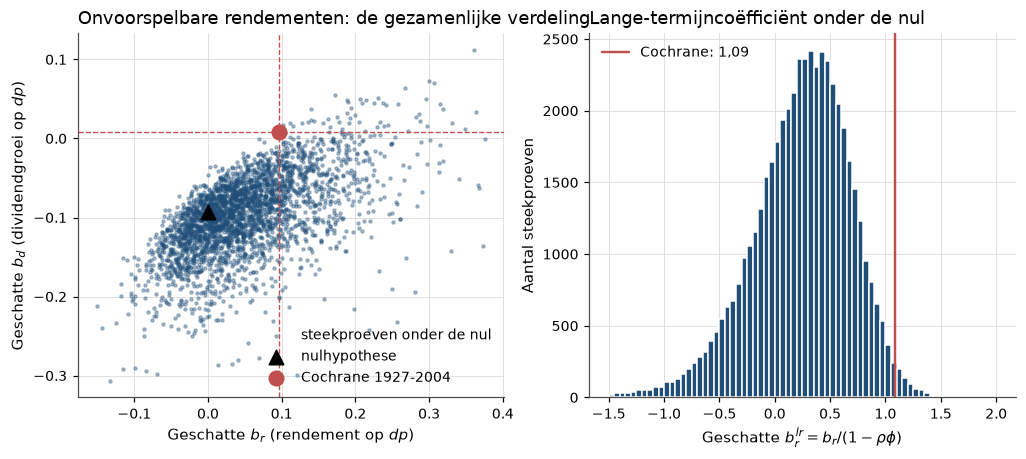

In [4]:
show = slice(0, 3000)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
ax = axes[0]
ax.scatter(br_null[show], bd_null[show], s=4, alpha=0.35, label="steekproeven onder de nul")
ax.scatter([0.0], [RHO_C * PHI_C - 1], marker="^", s=90, color="black", label="nulhypothese")
ax.scatter([SAMPLE_C["b_r"]], [SAMPLE_C["b_d"]], s=90, color=hap.plotting.COLORS[1],
           label="Cochrane 1927-2004")
ax.axvline(SAMPLE_C["b_r"], color=hap.plotting.COLORS[1], lw=0.9, ls="--")
ax.axhline(SAMPLE_C["b_d"], color=hap.plotting.COLORS[1], lw=0.9, ls="--")
ax.set_xlabel("Geschatte $b_r$ (rendement op $dp$)")
ax.set_ylabel("Geschatte $b_d$ (dividendgroei op $dp$)")
ax.set_title("Onvoorspelbare rendementen: de gezamenlijke verdeling")
ax.legend(loc="lower right")

ax = axes[1]
ax.hist(blr_null, bins=np.linspace(-1.5, 2.0, 71), edgecolor="white")
ax.axvline(SAMPLE_C["b_lr"], color=hap.plotting.COLORS[1], lw=1.6, label="Cochrane: 1,09")
ax.set_xlabel("Geschatte $b_r^{lr} = b_r/(1-\\rho\\phi)$")
ax.set_ylabel("Aantal steekproeven")
ax.set_title("Lange-termijncoëfficiënt onder de nul")
ax.legend()
plt.show()

:::{figure} #cel-voorspelbaarheid-hond
:label: fig-voorspelbaarheid-hond
:width: 100%

Links: 3000 van de 50 000 gesimuleerde steekproeven van 78 jaar met onvoorspelbare
rendementen. De wolk ligt schuin: een toevallig hoge $\hat b_r$ gaat samen met een hoge
$\hat b_d$, want beide volgen uit een te lage $\hat\phi$. Rechts van de verticale lijn
liggen veel steekproeven, boven de horizontale vrijwel geen. Rechts: de
lange-termijncoëfficiënt telt precies die hoek, en is daarom een krachtiger toets.
:::

De wolk heeft nog een tweede boodschap: zijn zwaartepunt ligt niet op nul. Het
gemiddelde van $\hat b_r$ onder de nul is de Stambaugh-bias, en we kunnen
[](#eq-voorspelbaarheid-stambaugh) er direct naast leggen.

In [5]:
sigma_uv = cov_shocks[0, 1] - RHO_C * SD_DP**2        # Cov(eps_r, eps_dp) from the identity
stambaugh = -(sigma_uv / SD_DP**2) * (1 + 3 * PHI_C) / T_C
pd.DataFrame(
    {"waarde": [br_null.mean(), stambaugh, phi_null.mean() - PHI_C, -(1 + 3 * PHI_C) / T_C]},
    index=["gemiddelde b_r-dak onder b_r = 0", "Stambaugh-formule",
           "gemiddelde phi-dak - phi", "Kendall: -(1 + 3 phi)/T"],
).round(4)

,waarde
gemiddelde b_r-dak onder b_r = 0,0.0492
Stambaugh-formule,0.0439
gemiddelde phi-dak - phi,-0.0553
Kendall: -(1 + 3 phi)/T,-0.0490


De formule voorspelt 0,044, de simulatie geeft ongeveer 0,05; het verschil komt
van de benadering $-(1+3\phi)/T$ voor de bias in $\hat\phi$, die bij $\phi$ dicht
bij één de werkelijke bias onderschat.

### Hoe vaak verliest echte voorspelbaarheid van het gemiddelde?

Nu de omgekeerde vraag. Stel dat Cochrane gelijk heeft: $b_r = 0{,}10$, en dus
$b_d = 0{,}10 + \rho\phi - 1 = 0{,}007$, dicht bij wat de data laten zien. De ware
éénjaars-$R^2$ is dan ongeveer 5%. Een belegger begint na 20 jaar data, schat elk
jaar opnieuw met een expanding window en voorspelt het volgende jaar. Hoe vaak eindigt
hij na $T$ jaar met een negatieve $R^2_{OOS}$? En hoe vaak zou dat gebeuren als hij
de ware helling kende?

In [6]:
def oos_r2_sim(n_samples, n_years, b_r=0.10, burn_in=20):
    """OOS R^2 of expanding-window OLS forecasts vs the expanding mean, per simulated sample."""
    dp, _, r = simulate_var(n_samples, n_years, b_r=b_r)
    x = dp[:, :-1]
    n = np.arange(1, n_years + 1)[burn_in - 1:-1]
    cum = lambda a: np.cumsum(a, axis=1)[:, burn_in - 1:-1]
    mx, my = cum(x) / n, cum(r) / n
    beta = (cum(x * r) / n - mx * my) / (cum(x * x) / n - mx**2)
    alpha = my - beta * mx
    target, x_now = r[:, burn_in:], x[:, burn_in:]
    sse_mean = ((target - my) ** 2).sum(axis=1)
    r2_est = 1 - ((target - alpha - beta * x_now) ** 2).sum(axis=1) / sse_mean
    r2_known = 1 - ((target - b_r * x_now) ** 2).sum(axis=1) / sse_mean
    return r2_est, r2_known


var_dp = SD_DP**2 / (1 - PHI_C**2)
var_eps_r = SD_D**2 + RHO_C**2 * SD_DP**2 - 2 * RHO_C * cov_shocks[0, 1]
print(f"ware een-jaars R^2: {0.10**2 * var_dp / (0.10**2 * var_dp + var_eps_r):.2%}")

horizons_T = [40, 60, 80, 100, 150, 200, 300]
oos_rows, r2_draws = [], {}
for T_years in horizons_T:
    r2_est, r2_known = oos_r2_sim(10_000, T_years)
    r2_draws[T_years] = r2_est
    oos_rows.append({"T (jaren)": T_years, "P(OOS R2 < 0), geschat": np.mean(r2_est < 0),
                     "P(OOS R2 < 0), ware helling": np.mean(r2_known < 0),
                     "mediaan OOS R2": np.median(r2_est)})
oos_table = pd.DataFrame(oos_rows).set_index("T (jaren)").round(3)
oos_table

ware een-jaars R^2: 5.07%


,"P(OOS R2 < 0), geschat","P(OOS R2 < 0), ware helling",mediaan OOS R2
T (jaren),,,
40,0.519,0.136,-0.006
60,0.503,0.076,-0.001
80,0.442,0.051,0.009
100,0.388,0.034,0.014
150,0.262,0.017,0.022
200,0.148,0.007,0.028
300,0.049,0.001,0.034


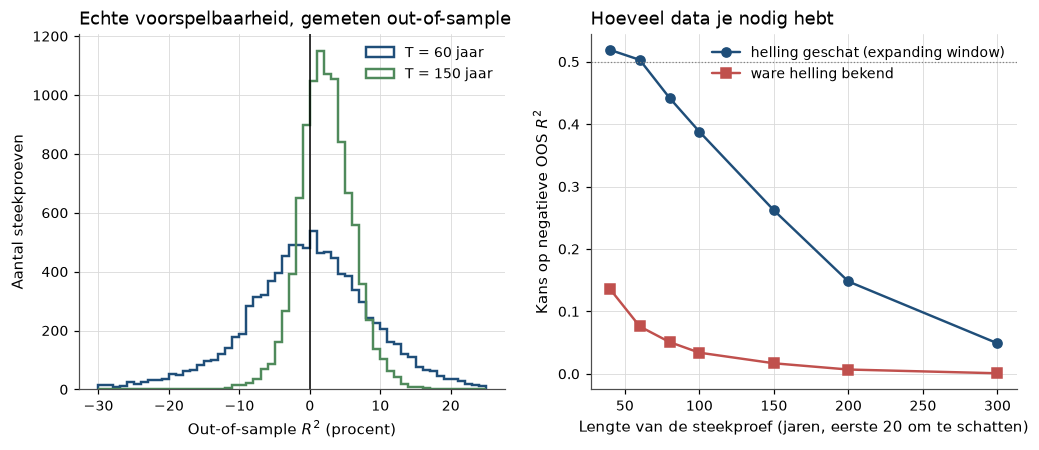

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for T_years, colour in [(60, hap.plotting.COLORS[0]), (150, hap.plotting.COLORS[2])]:
    axes[0].hist(100 * r2_draws[T_years], bins=np.linspace(-30, 25, 56), histtype="step",
                 lw=1.6, color=colour, label=f"T = {T_years} jaar")
axes[0].axvline(0, color="black", lw=1.0)
axes[0].set_xlabel("Out-of-sample $R^2$ (procent)")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].set_title("Echte voorspelbaarheid, gemeten out-of-sample")
axes[0].legend()

axes[1].plot(oos_table.index, oos_table["P(OOS R2 < 0), geschat"], marker="o",
             label="helling geschat (expanding window)")
axes[1].plot(oos_table.index, oos_table["P(OOS R2 < 0), ware helling"], marker="s",
             label="ware helling bekend")
axes[1].axhline(0.5, color="grey", lw=0.8, ls=":")
axes[1].set_xlabel("Lengte van de steekproef (jaren, eerste 20 om te schatten)")
axes[1].set_ylabel("Kans op negatieve OOS $R^2$")
axes[1].set_title("Hoeveel data je nodig hebt")
axes[1].legend()
plt.show()

:::{figure} #cel-voorspelbaarheid-oos-sim
:label: fig-voorspelbaarheid-oos-sim
:width: 100%

Een wereld waarin de dividend-prijsratio per constructie 5% van het
éénjaarsrendement voorspelt. Links: de out-of-sample $R^2$ na 60 en na 150 jaar.
Rechts: de kans dat de voorspeller het gemiddelde niet verslaat. Met 60 tot 80 jaar
data is dat een munt opgooien; na twee eeuwen nog een op de zeven. Wie de ware helling
kent, verliest bij 60 jaar in ongeveer 8% van de steekproeven.
:::

Dit is het 2%-motief in de taal van Goyal en Welch. Een negatieve $R^2_{OOS}$ is
nauwelijks bewijs tegen voorspelbaarheid; Cochrane vond in zijn eigen simulaties
"out-of-sample performance as bad or worse than that in the data" in 30–40% van de
steekproeven. Maar Goyal en Welch hebben gelijk voor de belegger: zolang de helling
geschat moet worden, is de winst in elke realistische steekproef klein en onzeker.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** (1) Fama en French, *Dividend Yields and Expected Stock Returns*, Journal
of Financial Economics 1988 {cite}`FamaFrench1988`. (2) Cochrane, *The Dog That Did
Not Bark: A Defense of Return Predictability*, Review of Financial Studies 2008
{cite}`Cochrane2008`. (3) Welch en Goyal, *A Comprehensive Look at the Empirical
Performance of Equity Premium Prediction*, Review of Financial Studies 2008
{cite}`GoyalWelch2008`, met de restricties van {cite:t}`CampbellThompson2008`. (4)
Ferreira en Santa-Clara, *Forecasting Stock Market Returns: The Sum of the Parts Is
More Than the Whole*, Journal of Financial Economics 2011
{cite}`FerreiraSantaClara2011`.

**Wat.** (1) Tabel 3: waardegewogen NYSE-rendementen op de dividendopbrengst voor
horizons van één tot vier jaar; over 1941–1986 met $D(t)/P(t)$ en nominale
rendementen stijgt de $R^2$ van 0,14 (één jaar) via 0,35 en 0,51 naar 0,64 (vier
jaar), met een vierjaarshelling van 15,35 ($t = 5{,}62$). (2) Tabel 1 en 2: over
1926–2004 $\hat b_r = 0{,}097$ ($t = 1{,}92$), $\hat b_d = 0{,}008$ ($t = 0{,}18$),
$\hat\phi = 0{,}941$, $\rho = 0{,}9638$; tabel 4: $\hat b_r^{lr} = 1{,}09$. (3)
Tabel 1, kolom "Forecasts begin 1965": de gecorrigeerde OOS-$\bar R^2$ over
1965–2005 in jaardata, onder meer $-3{,}69\%$ voor d/p, $-1{,}10\%$ voor e/p,
$-12{,}71\%$ voor b/m en $-2{,}96\%$ voor de term spread. (4) In de NBER-versie (2008,
sectie 3.2) geeft alleen dividendopbrengst plus winstgroei een $R^2_{OOS}$ van
1,32% in maanddata en 13,43% in jaardata over 1948–2007 (het abstract van het
tijdschriftartikel: "more than 1.3%" en "13.4%").

**Data hier.** `hap.data.goyal_welch("annual")` en `("monthly")`, 1871–2025. Voor (2)
volgen we Cochrane's voetnoot 5: $D_t/P_t = (1+R_t)/(1+R^x_t) - 1$ uit het
S&P 500-rendement met (`CRSP_SPvw`) en zonder dividend (`CRSP_SPvwx`), reëel gemaakt
met `infl`. Voor (1), (3) en (4) gebruiken we `D12`, `E12` en `Index`. Voor 1926
ontbreken CRSP-rendementen in het bestand; daar gebruiken we
$(P_t + D_t)/P_{t-1} - 1$ uit Shillers index, zoals Goyal en Welch zelf.

**Verschil met het origineel.** Fama en French gebruiken de NYSE-portefeuille van
CRSP, wij de S&P 500 van Goyal en Welch; Cochrane de hele CRSP-markt. Goyal en
Welch rapporteren een gecorrigeerde $\bar R^2$ met data tot 2005 en schatten vanaf
het begin van elke reeks; wij tonen ongecorrigeerde $R^2$, een gecorrigeerde versie
voor de vergelijking, en dezelfde regressies tot 2025. Ferreira en Santa-Clara
voegen in hun beste varianten een voorspelling van de groei van de
koers-winstverhouding toe; wij repliceren alleen de variant met die groei gelijk
aan nul.

**Verwachte afwijking.** (1) De $R^2$ moet monotoon stijgen met de horizon en op vier
jaar boven 0,5 liggen voor 1941–1986; over de volle steekproef tot 2025 moet hij
duidelijk lager zijn. (2) $\hat b_r$ positief tussen 0,07 en 0,13, $\hat b_d$ binnen
0,05 van nul, $\hat\phi$ tussen 0,90 en 0,97, en de identiteit
$\hat b_r - \hat b_d \approx 1 - \rho\hat\phi$ tot op 0,01. (3) Het *teken* van de
OOS-$R^2$ over 1965–2005 moet voor de grote meerderheid van de voorspellers negatief
zijn, zoals bij Goyal en Welch. (4) De sum-of-the-parts-$R^2_{OOS}$ moet positief
zijn, in maanddata in de orde van 1% en in jaardata in de orde van 10%, met een
Clark-West-$t$ boven 1,65. Wijkt een teken af, dan zit de fout in de code.
```

### De data

In [8]:
gw_a = hap_data.goyal_welch("annual")
gw_a.index = gw_a.index.year
gw_m = hap_data.goyal_welch("monthly")

# total S&P return: CRSP from 1926, Shiller index + dividends before (as Goyal-Welch do)
ret_a = gw_a["CRSP_SPvw"].fillna((gw_a["Index"] + gw_a["D12"]) / gw_a["Index"].shift(1) - 1)
log_ret_a = np.log1p(ret_a)
eq_prem_a = log_ret_a - np.log1p(gw_a["Rfree"])

# Cochrane's construction (footnote 5): dividends from returns with and without dividends
div_yield = (1 + gw_a["CRSP_SPvw"]) / (1 + gw_a["CRSP_SPvwx"]) - 1
price_idx = (1 + gw_a["CRSP_SPvwx"]).cumprod()
cochrane = pd.DataFrame(
    {
        "r": np.log1p(gw_a["CRSP_SPvw"]) - np.log1p(gw_a["infl"]),
        "dd": np.log(div_yield * price_idx).diff() - np.log1p(gw_a["infl"]),
        "dp": np.log(div_yield),
        "rex": np.log1p(gw_a["CRSP_SPvw"]) - np.log1p(gw_a["Rfree"]),
    }
)
cochrane.loc[1926:].describe().round(4)

,r,dd,dp,rex
count,100.0000,99.0000,100.0000,100.0000
mean,0.0695,0.0182,-3.3939,0.0654
std,0.1928,0.1408,0.4741,0.1928
min,-0.5096,-0.3648,-4.4668,-0.6171
25%,-0.0243,-0.0879,-3.8109,-0.0291
50%,0.1164,0.0256,-3.3270,0.0976
75%,0.2005,0.0966,-3.0408,0.1928
max,0.4304,0.3313,-2.5183,0.4232


### Fama en French: de $R^2$ stijgt met de horizon

In [9]:
def hodrick_tstat(r, x, h):
    """Hodrick (1992) 1B t-statistic for the slope of sum_{j=1..h} r_{t+j} on x_t.

    ``r`` and ``x`` are annual Series on the same integer index, already cut to the
    sample (returns for the years in the sample, predictor one year earlier).
    """  # TODO: naar hap.stats
    frame = pd.concat([r.rename("r"), x.rename("x")], axis=1)
    frame["y"] = frame["r"].rolling(h).sum().shift(-h)
    frame["x_sum"] = frame["x"].rolling(h).sum()
    frame["r_next"] = frame["r"].shift(-1)
    long = frame.dropna(subset=["y", "x"])
    X = np.column_stack([np.ones(len(long)), long["x"]])
    beta = np.linalg.lstsq(X, long["y"].to_numpy(), rcond=None)[0]
    one = frame.dropna(subset=["x_sum", "r_next"])
    u = (one["r_next"] - one["r_next"].mean()).to_numpy()
    Z = np.column_stack([np.full(len(one), float(h)), one["x_sum"]])
    xtx_inv = np.linalg.inv(X.T @ X)
    cov = xtx_inv @ ((Z * u[:, None] ** 2).T @ Z) @ xtx_inv
    return beta[1] / np.sqrt(cov[1, 1])


def ff_table(first, last, horizons=(1, 2, 3, 4)):
    """Fama-French (1988) style regressions of h-year log returns on D/P, one row per horizon."""
    r = log_ret_a.loc[first - 1:last]           # the first-1 return is never a target
    x = (gw_a["D12"] / gw_a["Index"]).loc[first - 1:last - 1]
    table = hap.long_horizon_regression(r, x, horizons=list(horizons))
    table["t (Hodrick 1B)"] = [hodrick_tstat(r, x, h) for h in horizons]
    return table.rename(columns={"beta": "helling", "tstat": "t (Hansen-Hodrick)"})


ff_1941 = ff_table(1941, 1986)
ff_1941["R2 Fama-French"] = [0.14, 0.35, 0.51, 0.64]
ff_1941[["helling", "t (Hansen-Hodrick)", "t (Hodrick 1B)", "r2", "R2 Fama-French", "nobs"]].round(3)

,helling,t (Hansen-Hodrick),t (Hodrick 1B),r2,R2 Fama-French,nobs
horizon,,,,,,
1,4.780,3.111,2.833,0.159,0.14,46
2,9.540,3.599,2.980,0.355,0.35,45
3,11.852,5.287,2.545,0.499,0.51,44
4,14.590,6.072,2.370,0.643,0.64,43


In [10]:
pd.concat(
    {f"{a}-{b}": ff_table(a, b)[["helling", "t (Hansen-Hodrick)", "t (Hodrick 1B)", "r2"]]
     for a, b in [(1927, 1986), (1927, 2025), (1950, 2025)]},
    names=["steekproef", "horizon (jaren)"],
).round(3)

helling  t (Hansen-Hodrick)  t (Hodrick 1B)     r2
steekproef horizon (jaren)                                                    
1927-1986  1                  2.284               1.141           1.278  0.027
           2                  6.579               2.493           1.978  0.104
           3                  8.521               3.259           2.015  0.133
           4                 11.401               5.042           2.188  0.191
1927-2025  1                  1.082               0.861           0.888  0.010
           2                  2.950               1.447           1.301  0.035
           3                  3.805               1.597           1.207  0.042
           4                  5.309               1.943           1.277  0.064
1950-2025  1                  3.319               2.815           2.382  0.081
           2                  5.835               2.757           2.206  0.134
           3                  7.148               2.884           1.791  0.159
           4                  9.144               3.351           1.657  0.209

Over 1941–1986 reproduceren we Fama en French' patroon bijna getal voor getal: de
$R^2$ loopt van 0,16 op één jaar via 0,36 en 0,50 naar 0,64 op vier jaar, tegen
0,14, 0,35, 0,51 en 0,64 in hun tabel 3, en de vierjaarshelling van ongeveer 14,6
ligt dicht bij hun 15,35. Twee dingen staan er ook. De Hansen-Hodrick-$t$ stijgt
mee met de horizon, van 3,1 naar 6,1, maar de Hodrick-1B-$t$ daalt zelfs licht, van
2,8 naar 2,4: het "extra bewijs" van de lange horizon is overlap, en de werkelijke
informatie zit al in het eerste jaar. En over de volle steekproef tot 2025 is er van
het patroon weinig over; de vierjaars-$R^2$ zakt naar 6%, met een Hodrick-$t$ van 1,3.
Naoorlogs (1950–2025) is het patroon er nog, zwakker: 0,21 op vier jaar, maar met een
Hodrick-$t$ die vanaf drie jaar onder de twee zakt. Dat is niet omdat de identiteit
niet meer geldt, maar omdat de
dividendopbrengst sinds 1990 op een ander niveau is gaan liggen (inkoop van eigen
aandelen vervangt dividend), en een regressie op niveaus dat als een grote,
nooit gecorrigeerde afwijking ziet.

### Cochrane: rendementen, dividenden en de identiteit

In [11]:
def predictive_ols(y, x):
    """OLS of y_{t+1} on x_t with heteroskedasticity-robust (HC0) t-statistics."""
    frame = pd.concat([y.shift(-1).rename("y"), x.rename("x")], axis=1).dropna()
    fit = sm.OLS(frame["y"], sm.add_constant(frame["x"])).fit(cov_type="HC0")
    return fit


def cochrane_table(first, last):
    """Cochrane (2008) Table 1/2: forecasts over first..last on dp from the year before."""
    sub = cochrane.loc[first - 1:last]
    x = sub["dp"].loc[: last - 1]
    fits = {name: predictive_ols(sub[col], x) for name, col in
            [("r", "r"), ("dd", "dd"), ("dp", "dp"), ("excess r", "rex")]}
    rho = np.exp(-sub["dp"].mean()) / (1 + np.exp(-sub["dp"].mean()))
    rows = {name: {"b": f.params["x"], "t": f.tvalues["x"], "R2 (%)": 100 * f.rsquared,
                   "n": int(f.nobs)} for name, f in fits.items()}
    table = pd.DataFrame(rows).T
    b_r, b_d, phi = table.loc["r", "b"], table.loc["dd", "b"], table.loc["dp", "b"]
    resid = pd.concat([fits["r"].resid, fits["dp"].resid], axis=1)
    s_uv = np.cov(resid.T)[0, 1] / np.var(fits["dp"].resid, ddof=1)
    extra = pd.Series(
        {"rho": rho, "1 - rho*phi + b_d": 1 - rho * phi + b_d,
         "b_r^lr": b_r / (1 - rho * phi), "b_d^lr": b_d / (1 - rho * phi),
         "b_r Stambaugh-gecorrigeerd": b_r + s_uv * (1 + 3 * phi) / table.loc["r", "n"]}
    )
    return table, extra


tab_2004, extra_2004 = cochrane_table(1927, 2004)
tab_2004["Cochrane b"] = [0.097, 0.008, 0.941, np.nan]
tab_2004["Cochrane t"] = [1.92, 0.18, np.nan, np.nan]
tab_2004.round(3)

,b,t,R2 (%),n,Cochrane b,Cochrane t
r,0.101,2.091,4.289,78.0,0.097,1.92
dd,0.002,0.051,0.004,78.0,0.008,0.18
dp,0.932,19.857,84.837,78.0,0.941,NaN
excess r,0.111,2.326,5.290,78.0,NaN,NaN


In [12]:
tab_2025, extra_2025 = cochrane_table(1927, 2025)
def summary_column(table, extra):
    """Stack slopes, the return t-statistic and the derived quantities into one column."""
    return pd.concat([table["b"].rename(lambda s: f"b ({s})"),
                      pd.Series({"t (r)": table.loc["r", "t"], "t (dd)": table.loc["dd", "t"]}),
                      extra])


pd.DataFrame(
    {"1927-2004": summary_column(tab_2004, extra_2004),
     "Cochrane (2008)": pd.Series({"b (r)": 0.097, "b (dd)": 0.008, "b (dp)": 0.941,
                                   "t (r)": 1.92, "t (dd)": 0.18,
                                   "rho": 0.9638, "b_r^lr": 1.09, "b_d^lr": 0.09}),
     "1927-2025": summary_column(tab_2025, extra_2025)}
).round(3)

,1927-2004,Cochrane (2008),1927-2025
1 - rho*phi + b_d,0.105,NaN,0.063
b (dd),0.002,0.008,-0.006
b (dp),0.932,0.941,0.962
b (excess r),0.111,NaN,0.061
b (r),0.101,0.097,0.062
b_d^lr,0.020,0.090,-0.086
b_r Stambaugh-gecorrigeerd,0.060,NaN,0.029
b_r^lr,0.981,1.090,0.905
rho,0.963,0.964,0.968
t (dd),0.051,0.180,-0.189


Op Cochrane's eigen steekproef komen we uit op $\hat b_r = 0{,}101$ ($t = 2{,}09$),
$\hat b_d = 0{,}002$ ($t = 0{,}05$) en $\hat\phi = 0{,}932$, tegen $0{,}097$, $0{,}008$ en
$0{,}941$: binnen een vijfde standaardfout, met S&P 500-dividenden in plaats van de
hele markt. De identiteit sluit tot op 0,004 en $\hat b_r^{lr} = 0{,}98$. De nul vroeg
om $b_d \approx -0{,}09$; de data geven nul.

De Stambaugh-correctie haalt ruim 0,04 van $\hat b_r$ af, bijna de helft, precies de
orde die [](#eq-voorspelbaarheid-stambaugh) voorspelde. Op de dividendhelling is de
correctie verwaarloosbaar: met Cochrane's getallen is
$\sigma_{d,dp}/\sigma_{dp}^2 = 0{,}075 \times 14{,}0/15{,}3 = 0{,}07$, en dus de bias
$0{,}07 \times 3{,}82/78 \approx 0{,}003$, omdat dividendschokken bijna ongecorreleerd zijn
met $dp$-schokken. Ook dat is een reden om naar de hond te kijken en niet naar de
rendementsregressie: het bewijs uit $\hat b_d$ is vrijwel niet vertekend.

Tot 2025 verzwakt de rendementsregressie ($\hat b_r = 0{,}062$, $t = 1{,}57$) en stijgt
$\hat\phi$ naar 0,96: de dividend-prijsratio is na 1995 laag gebleven. Maar
$\hat b_d$ blijft nul ($-0{,}006$), en daarmee blijft ook de conclusie staan dat de
beweging in $dp$ niet van dividenden komt. Wat wel verandert, is dat een $\phi$ dichter bij
$1/\rho$ de ruimte voor een coherente nulhypothese vergroot, precies de zwakke plek
die Cochrane zelf aanwees.

### Goyal en Welch: out-of-sample tegen het gemiddelde

In [13]:
PREDICTORS = ["dp", "dy", "ep", "de", "svar", "b/m", "ntis", "eqis",
              "tbl", "lty", "ltr", "tms", "dfy", "dfr", "infl", "ik"]
GW_PUBLISHED = {"dp": -3.69, "dy": -6.68, "ep": -1.10, "de": -4.99, "svar": -2.44,
                "b/m": -12.71, "ntis": -6.79, "eqis": -1.00, "tbl": -4.90, "lty": -12.57,
                "ltr": -18.38, "tms": -2.96, "dfy": -4.15, "dfr": -2.82, "infl": -3.56,
                "ik": -1.77}


def oos_forecasts(y, x, first, last, sign=None):
    """Expanding-window OLS forecasts of y_t from x_{t-1} and the expanding mean benchmark.

    With ``sign`` set, apply Campbell-Thompson: slope with the wrong sign -> use the
    mean; negative forecasts (and negative means) -> zero.
    """
    data = pd.concat([y.rename("y"), x.shift(1).rename("x")], axis=1).dropna()
    rows = []
    for year in data.loc[first:last].index:
        train = data.loc[: year - 1]
        slope, intercept = np.polyfit(train["x"], train["y"], 1)
        forecast, mean = intercept + slope * data.loc[year, "x"], train["y"].mean()
        if sign is not None:
            forecast = mean if np.sign(slope) != sign else forecast
            forecast, mean = max(forecast, 0.0), max(mean, 0.0)
        rows.append((year, data.loc[year, "y"], forecast, mean))
    return pd.DataFrame(rows, columns=["year", "y", "model", "mean"]).set_index("year")


def oos_stats(fc):
    """OOS R^2 (eq. oos) and the one-sided Clark-West t-statistic (eq. cw)."""
    err_model, err_mean = fc["y"] - fc["model"], fc["y"] - fc["mean"]
    r2 = 1 - (err_model**2).sum() / (err_mean**2).sum()
    f = err_mean**2 - (err_model**2 - (fc["mean"] - fc["model"]) ** 2)
    return r2, f.mean() / (f.std(ddof=1) / np.sqrt(len(f)))


gw_rows = {}
for name in PREDICTORS:
    r2_05, _ = oos_stats(oos_forecasts(eq_prem_a, gw_a[name], 1965, 2005))
    r2_25, cw_25 = oos_stats(oos_forecasts(eq_prem_a, gw_a[name], 1965, 2025))
    gw_rows[name] = {
        "OOS R2 1965-2005": 100 * r2_05,
        "idem, gecorrigeerd": 100 * (1 - (1 - r2_05) * (41 - 1) / (41 - 2)),
        "Goyal-Welch R2-streep": GW_PUBLISHED[name],
        "OOS R2 1965-2025": 100 * r2_25,
        "Clark-West t": cw_25,
    }
gw_table = pd.DataFrame(gw_rows).T
same_sign = np.mean(np.sign(gw_table["idem, gecorrigeerd"]) == np.sign(gw_table["Goyal-Welch R2-streep"]))
print(f"zelfde teken als Goyal-Welch: {same_sign:.0%} van de voorspellers")
gw_table.round(2)

zelfde teken als Goyal-Welch: 94% van de voorspellers


,OOS R2 1965-2005,"idem, gecorrigeerd",Goyal-Welch R2-streep,OOS R2 1965-2025,Clark-West t
dp,-1.67,-4.28,-3.69,-4.23,-0.01
dy,-4.98,-7.67,-6.68,-7.54,0.04
ep,1.05,-1.49,-1.10,-4.15,0.00
de,-2.56,-5.19,-4.99,-2.39,-2.11
svar,0.16,-2.40,-2.44,1.32,1.66
b/m,-11.91,-14.78,-12.71,-11.33,0.28
ntis,-5.05,-7.74,-6.79,-8.14,0.28
eqis,1.32,-1.21,-1.00,-0.68,1.29
tbl,-2.72,-5.35,-4.90,-1.04,0.94
lty,-10.40,-13.23,-12.57,-5.74,0.85


In [14]:
ct_rows = {}
for name in ["dp", "ep", "b/m", "tms"]:
    plain = oos_stats(oos_forecasts(eq_prem_a, gw_a[name], 1965, 2025))
    restricted = oos_stats(oos_forecasts(eq_prem_a, gw_a[name], 1965, 2025, sign=1))
    ct_rows[name] = {"OOS R2 zonder restricties": 100 * plain[0],
                     "OOS R2 met Campbell-Thompson": 100 * restricted[0],
                     "Clark-West t, met restricties": restricted[1]}
pd.DataFrame(ct_rows).T.round(2)

,OOS R2 zonder restricties,OOS R2 met Campbell-Thompson,"Clark-West t, met restricties"
dp,-4.23,-3.51,0.07
ep,-4.15,-1.89,0.23
b/m,-11.33,-10.01,0.34
tms,-1.01,-1.01,0.66


Het teken klopt: over 1965–2005 is de gecorrigeerde OOS-$\bar R^2$ bij 15 van de 16
voorspellers negatief, in dezelfde orde als bij Goyal en Welch (voor d/p
$-4{,}3\%$ tegen hun $-3{,}69\%$, voor b/m $-14{,}8\%$ tegen $-12{,}71\%$, voor de term
spread $-2{,}7\%$ tegen $-2{,}96\%$). De enige uitzondering is de
investment-capitalratio `ik`, die in de bijgewerkte data positief uitkomt; bij Goyal en
Welch begon die reeks twee jaar later en was hij negatief. Twintig jaar extra data
verandert het beeld nauwelijks: over 1965–2025 heeft de dividend-prijsratio een
$R^2_{OOS}$ van $-4{,}2\%$, en slechts twee voorspellers (`ik` en, net, `svar`) halen een
Clark-West-$t$ boven 1,65. De Campbell-Thompson-restricties helpen: voor e/p halveert het verlies
en voor b/m slinkt het, maar ze maken van geen van de vier een winnaar.

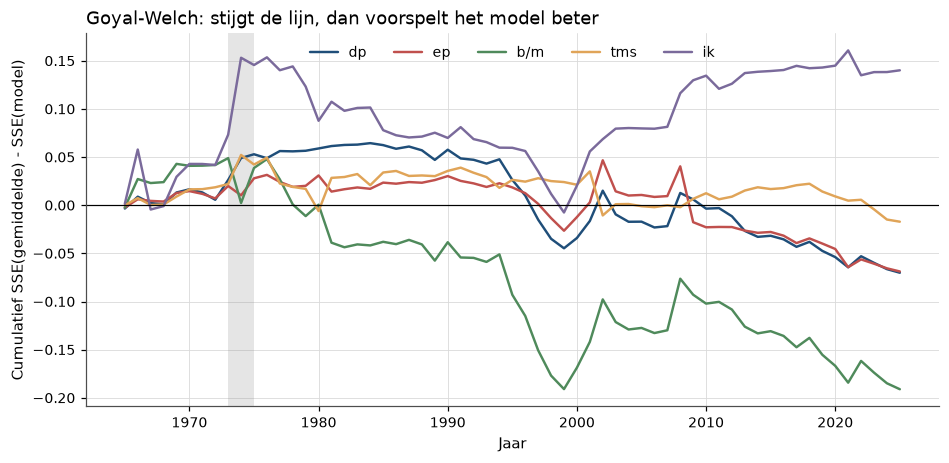

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.4))
for name, colour in zip(["dp", "ep", "b/m", "tms", "ik"], hap.plotting.COLORS):
    fc = oos_forecasts(eq_prem_a, gw_a[name], 1965, 2025)
    delta = ((fc["y"] - fc["mean"]) ** 2 - (fc["y"] - fc["model"]) ** 2).cumsum()
    ax.plot(delta.index, delta, color=colour, label=name)
ax.axhline(0, color="black", lw=0.8)
ax.axvspan(1973, 1975, color="grey", alpha=0.2, lw=0)
ax.set_xlabel("Jaar")
ax.set_ylabel("Cumulatief SSE(gemiddelde) - SSE(model)")
ax.set_title("Goyal-Welch: stijgt de lijn, dan voorspelt het model beter")
ax.legend(ncol=5)
plt.show()

:::{figure} #cel-voorspelbaarheid-cumsse
:label: fig-voorspelbaarheid-cumsse
:width: 95%

Cumulatief verschil in gekwadrateerde voorspelfouten tussen het historische
gemiddelde en vijf voorspellende regressies voor het log equity premium, met
expanding-window-schattingen vanaf 1965; de grijze band is de oliecrisis van
1973–1975. De dividend-prijsratio wint zijn voorsprong grotendeels in de crisis van
1973–1975 en verliest hem in de hausse van de late jaren negentig, toen lage ratio's
een lage premie voorspelden die pas rond 2000–2002 kwam; na 2008 zakken d/p en e/p
opnieuw weg. Dat is het instabiliteitsargument van Goyal en Welch: de prestaties
zitten in een paar jaren, en die jaren zijn niet steeds dezelfde.
:::

### Ferreira en Santa-Clara: de som van de delen

*Waarom zou dit werken?* Het log totaalrendement is exact de som van de groei van de
koers-winstverhouding, de groei van de winst en $\log(1 + D_{t+1}/P_{t+1})$
{cite}`FerreiraSantaClara2011`. Het eerste deel heeft een verwachting van ongeveer nul,
het tweede wordt goed benaderd door een lang gemiddelde, het derde is zo persistent
dat de huidige waarde volstaat. Er hoeft geen helling geschat te worden, en juist die
schattingsfout deed de regressie in de simulatie de das om.

De voorspelling voor jaar $s+1$ is dus $\E_s[r_{s+1}] = 0 + \bar g^{E}_{s,20} +
\log(1 + D_s/P_s)$, met $\bar g^{E}_{s,20}$ het gemiddelde van de log winstgroei over
de laatste twintig jaar. In maanddata delen we de laatste twee termen door 12 en
240. Het doel is het log *totaal*rendement (niet het equity premium), en de maatstaf
is het historische gemiddelde vanaf 1927; de voorspellingen beginnen in 1948.

In [16]:
def sop_oos(y, forecast, first, last, mean_from):
    """OOS R^2 and Clark-West t of a given forecast series (known at t-1) vs the expanding mean."""
    frame = pd.DataFrame({"y": y, "model": forecast.shift(1),
                          "mean": y.loc[mean_from:].expanding().mean().shift(1)})
    return oos_stats(frame.loc[first:last].dropna())


sop_annual = np.log(gw_a["E12"]).diff().rolling(20).mean() + np.log1p(gw_a["D12"] / gw_a["Index"])
sop_monthly = ((np.log(gw_m["E12"]) - np.log(gw_m["E12"].shift(240))) / 240
               + np.log1p(gw_m["D12"] / gw_m["Index"] / 12))
log_ret_m = np.log1p(gw_m["CRSP_SPvw"])

sop_rows = {}
for label, (first, last) in {"1948-2007": (1948, 2007), "1948-2025": (1948, 2025)}.items():
    r2_a, cw_a = sop_oos(log_ret_a, sop_annual, first, last, 1927)
    r2_m, cw_m = sop_oos(log_ret_m, sop_monthly, f"{first}-01", f"{last}-12", "1927-12")
    dp_reg = oos_stats(oos_forecasts(log_ret_a.loc[1927:], gw_a["dp"], first, last))
    sop_rows[label] = {"SOP maand: OOS R2 (%)": 100 * r2_m, "SOP maand: Clark-West t": cw_m,
                       "SOP jaar: OOS R2 (%)": 100 * r2_a, "SOP jaar: Clark-West t": cw_a,
                       "regressie op dp, jaar: OOS R2 (%)": 100 * dp_reg[0]}
sop_table = pd.DataFrame(sop_rows)
sop_table["Ferreira-Santa-Clara (1948-2007)"] = [1.32, np.nan, 13.43, np.nan, np.nan]
sop_table.round(2)

,1948-2007,1948-2025,Ferreira-Santa-Clara (1948-2007)
SOP maand: OOS R2 (%),1.32,0.70,1.32
SOP maand: Clark-West t,3.60,2.48,NaN
SOP jaar: OOS R2 (%),12.08,5.84,13.43
SOP jaar: Clark-West t,2.75,2.00,NaN
"regressie op dp, jaar: OOS R2 (%)",-0.47,-1.63,NaN


Over hun eigen periode, 1948–2007, geeft de som van de delen een $R^2_{OOS}$ van
1,32% in maanddata — gelijk aan het getal van Ferreira en Santa-Clara — en 12,1% in
jaardata, tegen hun 13,43%, met een Clark-West-$t$ van 3,6 en 2,8. Dezelfde
dividend-prijsratio als regressor met geschatte helling verliest over dezelfde jaren
van het gemiddelde: het verschil zit niet in de informatie maar in wat er geschat
moet worden. Tot 2025 halveert de $R^2_{OOS}$ ongeveer (de auteurs vonden zelf al een
zwakkere tweede helft), maar hij blijft positief en significant.

Volgens [](#eq-voorspelbaarheid-ct) is een maandelijkse $R^2$ van 1,32% bij
$S^2 \approx 1{,}2\%$ ruwweg een verdubbeling van het verwachte portefeuillerendement;
het tijdschriftartikel rapporteert een Sharpe-ratiowinst van 0,3.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** De Campbell-Shiller-identiteit maakte van de oude
vraag of rendementen voorspelbaar zijn een boekhoudkundige vraag met een exact
antwoord: de variantie van de dividend-prijsratio moet ergens heen, en de data
wijzen maar één kant op. Onze replicatie over 1927–2004 geeft een dividendhelling
van nul en een rendementshelling van 0,10; Cochrane's nulhypothese komt in onder de
2% van de gesimuleerde steekproeven zo ver. Het is hetzelfde feit dat in
[](#01-03-williams-ddm) de constante discontovoet verwierp en in
[](#03-15-shiller-excess-volatility) als excess volatility verscheen, en het verklaart
ook waarom de $R^2$ met de horizon groeit.

**Waar het breekt.** In het gebruik. Over 1965–2025 heeft de dividend-prijsratio
een out-of-sample $R^2$ van ongeveer $-4\%$, en de lange-horizon-$R^2$ van Fama en French
verdwijnt zodra de steekproef tot 2025 doorloopt. De simulatie laat zien dat dat te
verwachten is met 60 tot 80 jaar data, maar een voorspeller die de helft van de keren
van het gemiddelde verliest, is er geen om een pensioen op te bouwen. Alleen methoden
die bijna niets schatten, zoals de som van de delen, winnen stabiel. Het tweede moment
van $dp$ is uitstekend gemeten, de helling waarmee het rendementen voorspelt niet.

**Risico of vergissing?** Beide lezingen verklaren dezelfde tabel. De
Chicago-lezing, van Fama en Cochrane: de verwachte premie is hoog als beleggers arm
zijn en risico slecht verdragen, dus in en na recessies; prijzen zijn dan laag en
rendementen daarna hoog, en een belegger die dan koopt, draagt beprijsd risico. De
Yale-lezing, van Shiller: beleggers extrapoleren goede jaren, prijzen schieten door,
en de voorspelbaarheid is de langzame correctie van die vergissing. De identiteit
scheidt ze niet; ze zegt alleen *dat* de discontovoet beweegt, niet *waarom*.
Scheiden kan alleen een onafhankelijke meting: gaan hoge verwachte rendementen samen
met hoog marginaal nut (recessies, lage consumptie), of met aantoonbaar foute
verwachtingen van beleggers? Een overtuigende meting van dat soort bestaat nog niet. Voor Santa-Clara's praktijkmotief is het verschil concreet: wie
bijkoopt na een crash omdat de dividendopbrengst hoog is, oogst ofwel een
risicopremie die er blijvend is, ofwel denkt hij iets te weten wat de prijs niet
weet. Cochrane maakte van de eerste lezing het programma van zijn presidential
address {cite}`Cochrane2011`: als discontovoeten zo sterk variëren, moet elk
waarderingsvraagstuk, van aandelen tot obligaties en valuta, over discontovoeten
gaan en niet over kasstromen. Dat debat komt terug in
[Fama, Shiller en "Discount Rates"](#05-33-fama-vs-shiller).

**Wat er daarna kwam.** Als het eerste moment van rendementen zo moeilijk te
voorspellen is, dan is het tweede moment het tegenovergestelde: volatiliteit is
persistent, goed gemeten en uitstekend voorspelbaar, en daarover gaat
[ARCH, GARCH, realized volatility en de VIX](#04-21-volatiliteit).

## Oefeningen

:::{exercise}
:label: ex-voorspelbaarheid-1

**De $R^2$ op lange horizon in het VAR.** Neem het VAR
[](#eq-voorspelbaarheid-var) met $b_r = 0{,}10$, $\phi = 0{,}941$, $\rho = 0{,}9638$ en
de schokken uit Cochrane's tabel 2.

1. Leid af dat $\Cov(r_{t+1}, r_{t+1+j}) = b_r\phi^{j-1}\Cov(dp_{t+1}, r_{t+1})$ voor
   $j \ge 1$, en schrijf daarmee $\Var(r^{(k)}_t)$ als functie van $b_r$, $\phi$,
   $\Var(dp)$, $\Cov(\varepsilon^r, \varepsilon^{dp})$ en $\Var(\varepsilon^r)$.
2. Bereken de populatie-$R^2(k)$ uit [](#eq-voorspelbaarheid-r2k) voor
   $k = 1, 2, 5, 10$, en vergelijk met de naïeve formule
   $R^2(1)[(1-\phi^k)/(1-\phi)]^2/k$.
3. Controleer (2) met een simulatie van één lang pad van 200 000 jaar.
:::

:::{solution} ex-voorspelbaarheid-1
:class: dropdown

**(1)** Voor $j \ge 1$ is $r_{t+1+j} = a_r + b_r\,dp_{t+j} + \varepsilon^r_{t+1+j}$, en de
laatste schok is onafhankelijk van $r_{t+1}$. Dus
$\Cov(r_{t+1}, r_{t+1+j}) = b_r\Cov(r_{t+1}, dp_{t+j})$. Uit de AR(1) volgt
$dp_{t+j} = \phi^{j-1}dp_{t+1} + (\text{schokken na } t+1)$, dus
$\Cov(r_{t+1}, r_{t+1+j}) = b_r\phi^{j-1}\Cov(dp_{t+1}, r_{t+1})$, met

$$
\Cov(dp_{t+1}, r_{t+1}) = \Cov\big(\phi\,dp_t + \varepsilon^{dp}_{t+1},\ b_r dp_t + \varepsilon^r_{t+1}\big)
= \phi\, b_r\Var(dp) + \sigma_{r,dp} .
$$

Tel de covarianties op over alle paren binnen het $k$-jaarsvenster:
$\Var(r^{(k)}) = k\Var(r) + 2\sum_{j=1}^{k-1}(k-j)\,b_r\phi^{j-1}\Cov(dp_{t+1}, r_{t+1})$,
met $\Var(r) = b_r^2\Var(dp) + \Var(\varepsilon^r)$. Omdat $\sigma_{r,dp}$ sterk negatief is,
is $\Cov(dp_{t+1}, r_{t+1}) < 0$: rendementen zijn negatief autogecorreleerd, het
discount-rate effect van Fama en French.

**(2) en (3)**

In [17]:
b_ex = 0.10
var_dp_ex = SD_DP**2 / (1 - PHI_C**2)
s_r_dp = cov_shocks[0, 1] - RHO_C * SD_DP**2
var_r_ex = b_ex**2 * var_dp_ex + var_eps_r
cov_dp1_r1 = PHI_C * b_ex * var_dp_ex + s_r_dp


def r2_horizon(k):
    """Population R^2 of k-year returns on dp in the VAR."""
    var_k = k * var_r_ex + 2 * sum((k - j) * b_ex * PHI_C ** (j - 1) * cov_dp1_r1 for j in range(1, k))
    return (b_ex * (1 - PHI_C**k) / (1 - PHI_C)) ** 2 * var_dp_ex / var_k


dp_long, _, r_long = simulate_var(1, 200_000, b_r=b_ex)
dp_long, r_long = pd.Series(dp_long[0, :-1]), pd.Series(r_long[0])
rows_ex1 = {}
for k in (1, 2, 5, 10):
    cum_r = r_long.rolling(k).sum().shift(-(k - 1))
    ok = cum_r.notna()
    rows_ex1[k] = {"R2 formule": r2_horizon(k),
                   "R2 naief": r2_horizon(1) * ((1 - PHI_C**k) / (1 - PHI_C)) ** 2 / k,
                   "R2 simulatie": np.corrcoef(dp_long[ok], cum_r[ok])[0, 1] ** 2}
pd.DataFrame(rows_ex1).T.rename_axis("horizon k").round(4)

,R2 formule,R2 naief,R2 simulatie
horizon k,,,
1,0.0507,0.0507,0.0498
2,0.0960,0.0956,0.0944
5,0.2036,0.2004,0.2002
10,0.3129,0.3026,0.3077


De formule en de simulatie liggen binnen enkele tienden van een procentpunt van
elkaar, en de formule ligt boven de naïeve berekening: de negatieve autocorrelatie van rendementen die uit $\sigma_{r,dp} < 0$
volgt, remt de groei van $\Var(r^{(k)})$ en duwt de $R^2$ omhoog. Les: de stijgende
$R^2$ volgt volledig uit $b_r$, $\phi$ en de schokcorrelatie; de lange horizon voegt
geen informatie toe.
:::

:::{exercise}
:label: ex-voorspelbaarheid-2

**Excess rendementen en de naoorlogse steekproef.** Herhaal de Cochrane-tabel voor
1947–2025 en rapporteer $\hat b_r$ voor reële én excess rendementen, $\hat b_d$,
$\hat\phi$, de Stambaugh-gecorrigeerde $\hat b_r$ en $\hat b_r^{lr}$. Simuleer daarna
Cochrane's nulhypothese met de $\hat\phi$ en de lengte van deze steekproef, en
rapporteer $P(\hat b_d > \text{schatting})$. Is de hond ook naoorlogs stil?
:::

:::{solution} ex-voorspelbaarheid-2
:class: dropdown

In [18]:
tab_post, extra_post = cochrane_table(1947, 2025)
n_post = int(tab_post.loc["r", "n"])
phi_post = tab_post.loc["dp", "b"]

dp_p, dd_p, r_p = simulate_var(20_000, n_post, b_r=0.0, phi=phi_post)
bd_sim_post = slopes(dd_p, dp_p[:, :-1])
br_sim_post = slopes(r_p, dp_p[:, :-1])

print(f"n = {n_post}, phi-dak = {phi_post:.3f}, b_d onder de nul = {RHO_C * phi_post - 1:.3f}")
print(f"P(b_r-dak > schatting) onder de nul: {np.mean(br_sim_post > tab_post.loc['r', 'b']):.3f}")
print(f"P(b_d-dak > schatting) onder de nul: {np.mean(bd_sim_post > tab_post.loc['dd', 'b']):.3f}")
pd.concat([tab_post[["b", "t", "R2 (%)"]], extra_post.to_frame("b")]).round(3)

n = 79, phi-dak = 0.978, b_d onder de nul = -0.057
P(b_r-dak > schatting) onder de nul: 0.307
P(b_d-dak > schatting) onder de nul: 0.024


,b,t,R2 (%)
r,0.075,1.875,4.217
dd,0.023,0.646,0.687
dp,0.978,28.358,91.860
excess r,0.069,1.723,3.728
rho,0.971,NaN,NaN
1 - rho*phi + b_d,0.073,NaN,NaN
b_r^lr,1.477,NaN,NaN
b_d^lr,0.451,NaN,NaN
b_r Stambaugh-gecorrigeerd,0.035,NaN,NaN


Naoorlogs is $\hat\phi = 0{,}978$, dus eist de nul maar $b_d = -0{,}057$. De
rendementsregressie is marginaal ($\hat b_r = 0{,}075$, $t = 1{,}88$) en halveert na de
Stambaugh-correctie; de dividendhelling is licht positief, wat onder de nul in
ongeveer 2% van de steekproeven voorkomt: de hond is ook naoorlogs stil. Bij
$\rho\hat\phi = 0{,}95$ blazen $\hat b_r^{lr}$ en $\hat b_d^{lr}$ allebei op, terwijl hun
verschil één blijft. Les: hoe dichter $\hat\phi$ bij $1/\rho$, hoe minder de hond hoeft
te blaffen om de nul te steunen.
:::